In [ ]:
from pathlib import Path
import os
import sys

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "src").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate
    raise RuntimeError("Project root was not found. Open this notebook from inside the project folder.")

PROJECT_ROOT = find_project_root()
ROOT = PROJECT_ROOT
root = PROJECT_ROOT
project_root = PROJECT_ROOT

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Working directory:", Path.cwd())


# Cane Corso Growth Intelligence

## Feature Engineering and Time Series Growth Signals

This notebook applies the **Feature Engineering and Time Series** lecture to the Cane Corso Growth Intelligence project.

The goal is not to build the most advanced production model yet. At this stage I am learning how raw measurements can be transformed into more meaningful mathematical signals before they are used by machine learning models.

In simple words:

```text
raw growth records -> mathematical features -> time-based growth signals -> better ML interpretation
```

The project remains educational. It does **not** provide veterinary diagnosis, medical advice, pedigree proof, or breed certification.

## 1. Learning Objective

In the previous notebooks I used:

- **Regression** to predict a numerical growth value.
- **Classification** to estimate whether a record looks normal or needs attention.
- **Clustering** to discover natural growth-pattern groups without labels.

In this notebook I focus on the stage before modelling:

```text
How can I create better input features from age, weight and height records?
```

This matters because a single measurement does not describe the full growth story. For a large breed, the **change over time** is often more informative than one isolated value.

## 2. Mathematical Problem Formulation

A growth record for dog `i` at time stage `t` can be written as:

```text
r(i,t) = [age_months(i,t), weight_kg(i,t), height_cm(i,t)]
```

For time-series reasoning, the order matters:

```text
r(i,1), r(i,2), r(i,3), ..., r(i,T)
```

The feature engineering function transforms raw records into a richer vector:

```text
phi(r(i,t), r(i,t-1)) = engineered growth features
```

This notebook does not optimize a predictive loss function directly. Instead, it creates features that can later be used by regression, classification, clustering, dimensionality reduction, or MLflow experiment tracking.

## 3. Core Formulas

For consecutive measurements of the same dog:

```text
weight_gain(t) = weight(t) - weight(t-1)
```

```text
height_gain(t) = height(t) - height(t-1)
```

```text
delta_age(t) = age(t) - age(t-1)
```

The growth velocity is:

```text
growth_velocity(t) = weight_gain(t) / delta_age(t)
```

A simple body proportion feature is:

```text
weight_to_height_ratio(t) = weight_kg(t) / height_cm(t)
```

A rolling mean smooths short-term changes:

```text
rolling_mean_k(t) = (x(t) + x(t-1) + ... + x(t-k+1)) / k
```

A z-score compares a value with the average pattern:

```text
z = (value - mean) / standard_deviation
```

These formulas make the notebook more mathematical while still staying understandable for a learner.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root() -> Path:
    current = Path.cwd()
    if (current / "data").exists():
        return current
    if (current.parent / "data").exists():
        return current.parent
    raise RuntimeError("Project root with data/ folder was not found.")


project_root = find_project_root()
prototype_path = project_root / "data" / "prototype" / "cane_corso_growth_sample.csv"
processed_output_path = project_root / "data" / "processed" / "cane_corso_time_series_features.csv"
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Prototype data:", prototype_path)
print("Output feature data:", processed_output_path)

Project root: /mnt/data/ccgi_step10_work
Prototype data: /mnt/data/ccgi_step10_work/data/prototype/cane_corso_growth_sample.csv
Output feature data: /mnt/data/ccgi_step10_work/data/processed/cane_corso_time_series_features.csv


## 4. Data Used in This Notebook

For the time-series demonstration I use the small prototype Cane Corso sample:

```text
data/prototype/cane_corso_growth_sample.csv
```

Reason: this file contains repeated measurements for the same dogs over age, which is useful for explaining time-based features.

The project still keeps the real public dog growth dataset as the stronger data foundation for broader regression, classification and clustering experiments. This notebook is mainly about learning the mathematics of temporal feature creation.

In [2]:
raw_df = pd.read_csv(prototype_path)
raw_df = raw_df.sort_values(["dog_id", "age_months"]).reset_index(drop=True)

print("Rows:", len(raw_df))
print("Columns:", len(raw_df.columns))
raw_df.head(10)

Rows: 32
Columns: 8


,dog_id,dog_name,sex,age_months,weight_kg,height_cm,activity_level,source_type
0,1,Ares,male,2,9.5,32,medium,prototype
1,1,Ares,male,3,14.2,38,medium,prototype
2,1,Ares,male,4,20.1,45,medium,prototype
3,1,Ares,male,5,26.4,51,medium,prototype
4,1,Ares,male,6,31.8,56,medium,prototype
5,1,Ares,male,8,38.5,61,medium,prototype
6,1,Ares,male,10,43.2,64,medium,prototype
7,1,Ares,male,12,46.7,66,medium,prototype
8,2,Bruna,female,2,8.7,31,medium,prototype
9,2,Bruna,female,3,13.1,37,medium,prototype


## 5. Create Time-Based Features

The important rule is that each dog must be sorted by age before calculating differences.

For example, `weight_gain_kg` only makes sense if the previous row is the previous measurement of the same dog.

In [3]:
features_df = raw_df.copy()
features_df = features_df.sort_values(["dog_id", "age_months"]).reset_index(drop=True)

grouped = features_df.groupby("dog_id", sort=False)

features_df["previous_age_months"] = grouped["age_months"].shift(1)
features_df["previous_weight_kg"] = grouped["weight_kg"].shift(1)
features_df["previous_height_cm"] = grouped["height_cm"].shift(1)

features_df["delta_age_months"] = features_df["age_months"] - features_df["previous_age_months"]
features_df["weight_gain_kg"] = features_df["weight_kg"] - features_df["previous_weight_kg"]
features_df["height_gain_cm"] = features_df["height_cm"] - features_df["previous_height_cm"]

features_df["growth_velocity_kg_per_month"] = (
    features_df["weight_gain_kg"] / features_df["delta_age_months"]
)
features_df["height_velocity_cm_per_month"] = (
    features_df["height_gain_cm"] / features_df["delta_age_months"]
)

features_df["weight_to_height_ratio"] = features_df["weight_kg"] / features_df["height_cm"]
features_df["lag_weight_kg"] = features_df["previous_weight_kg"]
features_df["lag_height_cm"] = features_df["previous_height_cm"]

features_df[[
    "dog_name",
    "age_months",
    "weight_kg",
    "previous_weight_kg",
    "weight_gain_kg",
    "growth_velocity_kg_per_month",
    "weight_to_height_ratio",
]].head(12)

,dog_name,age_months,weight_kg,previous_weight_kg,weight_gain_kg,growth_velocity_kg_per_month,weight_to_height_ratio
0,Ares,2,9.5,NaN,NaN,NaN,0.296875
1,Ares,3,14.2,9.5,4.7,4.70,0.373684
2,Ares,4,20.1,14.2,5.9,5.90,0.446667
3,Ares,5,26.4,20.1,6.3,6.30,0.517647
4,Ares,6,31.8,26.4,5.4,5.40,0.567857
5,Ares,8,38.5,31.8,6.7,3.35,0.631148
6,Ares,10,43.2,38.5,4.7,2.35,0.675000
7,Ares,12,46.7,43.2,3.5,1.75,0.707576
8,Bruna,2,8.7,NaN,NaN,NaN,0.280645
9,Bruna,3,13.1,8.7,4.4,4.40,0.354054


## 6. Rolling Average Features

A rolling average is useful because growth measurements can fluctuate. Instead of reacting to one value only, a rolling mean looks at a small window of recent records.

For this beginner-friendly notebook I use a window of 3 records:

```text
rolling_weight_mean_3(t) = average of current and previous two weight records
```

This is not a medical judgement. It is a mathematical smoothing technique.

In [4]:
features_df["rolling_weight_mean_3"] = grouped["weight_kg"].transform(
    lambda values: values.rolling(window=3, min_periods=1).mean()
)
features_df["rolling_height_mean_3"] = grouped["height_cm"].transform(
    lambda values: values.rolling(window=3, min_periods=1).mean()
)
features_df["rolling_growth_velocity_3"] = features_df.groupby("dog_id", sort=False)[
    "growth_velocity_kg_per_month"
].transform(lambda values: values.rolling(window=3, min_periods=1).mean())

features_df[[
    "dog_name",
    "age_months",
    "weight_kg",
    "rolling_weight_mean_3",
    "growth_velocity_kg_per_month",
    "rolling_growth_velocity_3",
]].head(12)

,dog_name,age_months,weight_kg,rolling_weight_mean_3,growth_velocity_kg_per_month,rolling_growth_velocity_3
0,Ares,2,9.5,9.500000,NaN,NaN
1,Ares,3,14.2,11.850000,4.70,4.700000
2,Ares,4,20.1,14.600000,5.90,5.300000
3,Ares,5,26.4,20.233333,6.30,5.633333
4,Ares,6,31.8,26.100000,5.40,5.866667
5,Ares,8,38.5,32.233333,3.35,5.016667
6,Ares,10,43.2,37.833333,2.35,3.700000
7,Ares,12,46.7,42.800000,1.75,2.483333
8,Bruna,2,8.7,8.700000,NaN,NaN
9,Bruna,3,13.1,10.900000,4.40,4.400000


## 7. Growth Phase Feature

Feature engineering can also create categorical features from numeric values.

Here I create a simple learning-oriented growth phase from age in months:

```text
0-4 months   -> early_puppy
5-8 months   -> juvenile
9-12 months  -> adolescent
13+ months   -> young_adult
```

These ranges are simplified for the course project. They are not a veterinary standard.

In [5]:
def growth_phase(age_months: float) -> str:
    if age_months <= 4:
        return "early_puppy"
    if age_months <= 8:
        return "juvenile"
    if age_months <= 12:
        return "adolescent"
    return "young_adult"


features_df["growth_phase"] = features_df["age_months"].apply(growth_phase)

phase_summary = (
    features_df.groupby("growth_phase")
    .agg(
        records=("dog_id", "count"),
        avg_age_months=("age_months", "mean"),
        avg_weight_kg=("weight_kg", "mean"),
        avg_height_cm=("height_cm", "mean"),
        avg_velocity_kg_per_month=("growth_velocity_kg_per_month", "mean"),
    )
    .round(2)
)
phase_summary

,records,avg_age_months,avg_weight_kg,avg_height_cm,avg_velocity_kg_per_month
growth_phase,,,,,
adolescent,8,11.00,42.64,63.38,1.86
early_puppy,12,3.00,14.11,37.83,5.19
juvenile,12,6.33,30.63,54.67,4.65


## 8. Z-Score Growth Velocity Signal

A z-score shows how far a value is from the mean in standard deviation units:

```text
z = (x - mean) / standard_deviation
```

In this notebook I apply it to growth velocity. This creates a simple mathematical signal:

- `z >= 1` means faster than the average gain in this small sample.
- `z <= -1` means slower than the average gain in this small sample.
- otherwise the value is inside the average band.

This is only an educational signal. It does not mean that a dog is healthy or unhealthy.

In [6]:
mean_velocity = features_df["growth_velocity_kg_per_month"].mean(skipna=True)
std_velocity = features_df["growth_velocity_kg_per_month"].std(skipna=True)

features_df["growth_velocity_z_score"] = (
    features_df["growth_velocity_kg_per_month"] - mean_velocity
) / std_velocity


def velocity_signal(z_score: float) -> str:
    if pd.isna(z_score):
        return "first_record_no_previous_measurement"
    if z_score >= 1.0:
        return "faster_than_average_gain"
    if z_score <= -1.0:
        return "slower_than_average_gain"
    return "within_average_gain_band"


features_df["growth_velocity_signal"] = features_df["growth_velocity_z_score"].apply(velocity_signal)

features_df[[
    "dog_name",
    "age_months",
    "growth_velocity_kg_per_month",
    "growth_velocity_z_score",
    "growth_velocity_signal",
]].head(16)

,dog_name,age_months,growth_velocity_kg_per_month,growth_velocity_z_score,growth_velocity_signal
0,Ares,2,NaN,NaN,first_record_no_previous_measurement
1,Ares,3,4.70,0.412784,within_average_gain_band
2,Ares,4,5.90,1.127709,faster_than_average_gain
3,Ares,5,6.30,1.366017,faster_than_average_gain
4,Ares,6,5.40,0.829824,within_average_gain_band
5,Ares,8,3.35,-0.391507,within_average_gain_band
6,Ares,10,2.35,-0.987277,within_average_gain_band
7,Ares,12,1.75,-1.344740,slower_than_average_gain
8,Bruna,2,NaN,NaN,first_record_no_previous_measurement
9,Bruna,3,4.40,0.234053,within_average_gain_band


## 9. Save the Engineered Feature Dataset

The result of this notebook becomes a new processed dataset:

```text
data/processed/cane_corso_time_series_features.csv
```

This keeps the workflow reproducible: later notebooks can use the same engineered features for dimensionality reduction, model comparison or experiment tracking.

In [7]:
features_df.to_csv(processed_output_path, index=False)
print("Saved engineered feature dataset to:", processed_output_path)
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))

Saved engineered feature dataset to: /mnt/data/ccgi_step10_work/data/processed/cane_corso_time_series_features.csv
Rows: 32
Columns: 25


## 10. Visualize the Time Series

The first visualization shows weight trajectory over age.

This is the simplest form of time-series interpretation: the x-axis is time and the y-axis is the measured value.

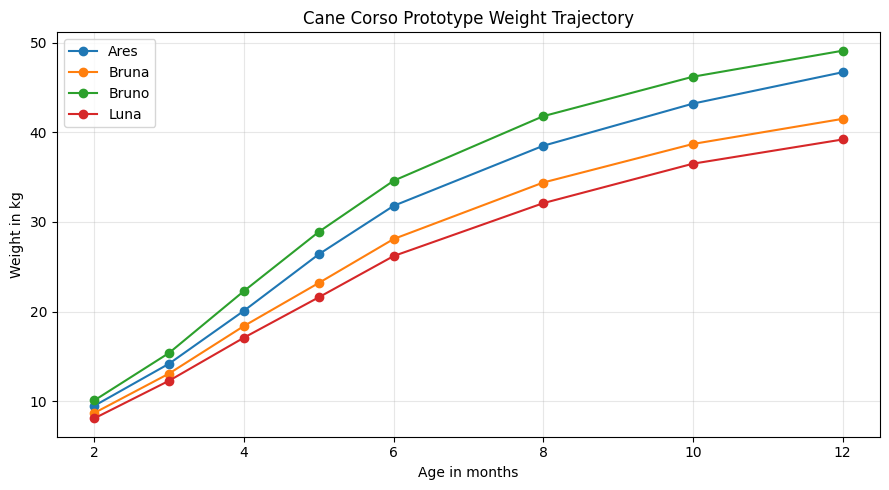

Saved figure: /mnt/data/ccgi_step10_work/reports/figures/time_series_weight_trajectory.png


In [8]:
plt.figure(figsize=(9, 5))
for dog_name, dog_data in features_df.groupby("dog_name"):
    plt.plot(dog_data["age_months"], dog_data["weight_kg"], marker="o", label=dog_name)

plt.title("Cane Corso Prototype Weight Trajectory")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

weight_trajectory_path = figures_dir / "time_series_weight_trajectory.png"
plt.savefig(weight_trajectory_path, dpi=160)
plt.show()

print("Saved figure:", weight_trajectory_path)

## 11. Visualize Growth Velocity

The next chart uses the engineered feature:

```text
growth_velocity_kg_per_month
```

This makes the notebook more connected to the lecture because I am not only plotting raw data; I am plotting a feature created from a mathematical transformation.

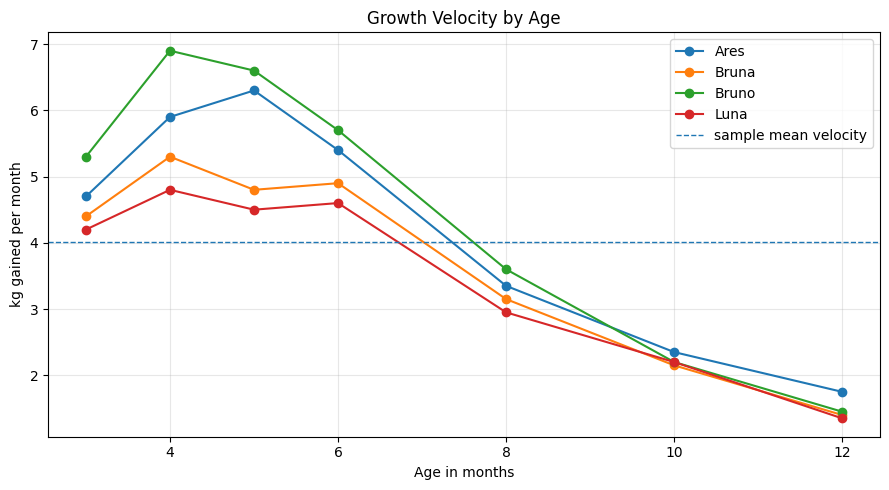

Saved figure: /mnt/data/ccgi_step10_work/reports/figures/time_series_growth_velocity.png


In [9]:
plt.figure(figsize=(9, 5))
for dog_name, dog_data in features_df.groupby("dog_name"):
    plt.plot(
        dog_data["age_months"],
        dog_data["growth_velocity_kg_per_month"],
        marker="o",
        label=dog_name,
    )

plt.title("Growth Velocity by Age")
plt.xlabel("Age in months")
plt.ylabel("kg gained per month")
plt.axhline(mean_velocity, linestyle="--", linewidth=1, label="sample mean velocity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

velocity_path = figures_dir / "time_series_growth_velocity.png"
plt.savefig(velocity_path, dpi=160)
plt.show()

print("Saved figure:", velocity_path)

## 12. Visualize Rolling Average

A rolling average can make a growth curve smoother and easier to interpret.

This is useful for learning because it shows a common time-series idea without making the project too advanced too early.

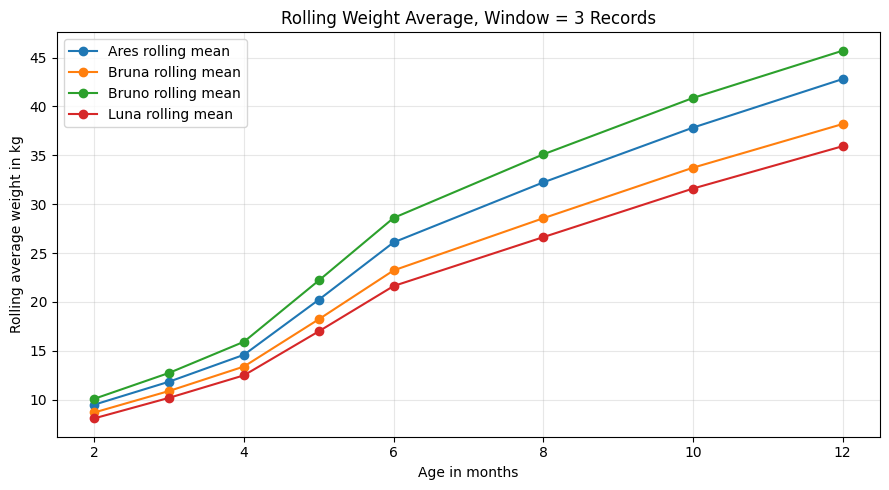

Saved figure: /mnt/data/ccgi_step10_work/reports/figures/time_series_rolling_weight_average.png


In [10]:
plt.figure(figsize=(9, 5))
for dog_name, dog_data in features_df.groupby("dog_name"):
    plt.plot(
        dog_data["age_months"],
        dog_data["rolling_weight_mean_3"],
        marker="o",
        label=f"{dog_name} rolling mean",
    )

plt.title("Rolling Weight Average, Window = 3 Records")
plt.xlabel("Age in months")
plt.ylabel("Rolling average weight in kg")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

rolling_path = figures_dir / "time_series_rolling_weight_average.png"
plt.savefig(rolling_path, dpi=160)
plt.show()

print("Saved figure:", rolling_path)

## 13. Feature Correlation Check

Feature engineering can create useful features, but it can also create redundant features.

A correlation matrix is a simple mathematical check. If two features are very strongly correlated, they may carry similar information.

In [11]:
numeric_features = [
    "age_months",
    "weight_kg",
    "height_cm",
    "weight_gain_kg",
    "height_gain_cm",
    "growth_velocity_kg_per_month",
    "height_velocity_cm_per_month",
    "weight_to_height_ratio",
    "rolling_weight_mean_3",
    "rolling_growth_velocity_3",
]

correlation_matrix = features_df[numeric_features].corr().round(2)
correlation_matrix

,age_months,weight_kg,height_cm,weight_gain_kg,height_gain_cm,growth_velocity_kg_per_month,height_velocity_cm_per_month,weight_to_height_ratio,rolling_weight_mean_3,rolling_growth_velocity_3
age_months,1.00,0.95,0.93,-0.49,-0.93,-0.87,-0.96,0.94,0.97,-0.76
weight_kg,0.95,1.00,0.99,-0.23,-0.81,-0.71,-0.89,0.99,0.99,-0.50
height_cm,0.93,0.99,1.00,-0.17,-0.78,-0.66,-0.87,1.00,0.97,-0.44
weight_gain_kg,-0.49,-0.23,-0.17,1.00,0.70,0.65,0.46,-0.19,-0.33,0.83
height_gain_cm,-0.93,-0.81,-0.78,0.70,1.00,0.87,0.92,-0.80,-0.86,0.82
growth_velocity_kg_per_month,-0.87,-0.71,-0.66,0.65,0.87,1.00,0.92,-0.68,-0.77,0.92
height_velocity_cm_per_month,-0.96,-0.89,-0.87,0.46,0.92,0.92,1.00,-0.88,-0.92,0.77
weight_to_height_ratio,0.94,0.99,1.00,-0.19,-0.80,-0.68,-0.88,1.00,0.97,-0.47
rolling_weight_mean_3,0.97,0.99,0.97,-0.33,-0.86,-0.77,-0.92,0.97,1.00,-0.58
rolling_growth_velocity_3,-0.76,-0.50,-0.44,0.83,0.82,0.92,0.77,-0.47,-0.58,1.00


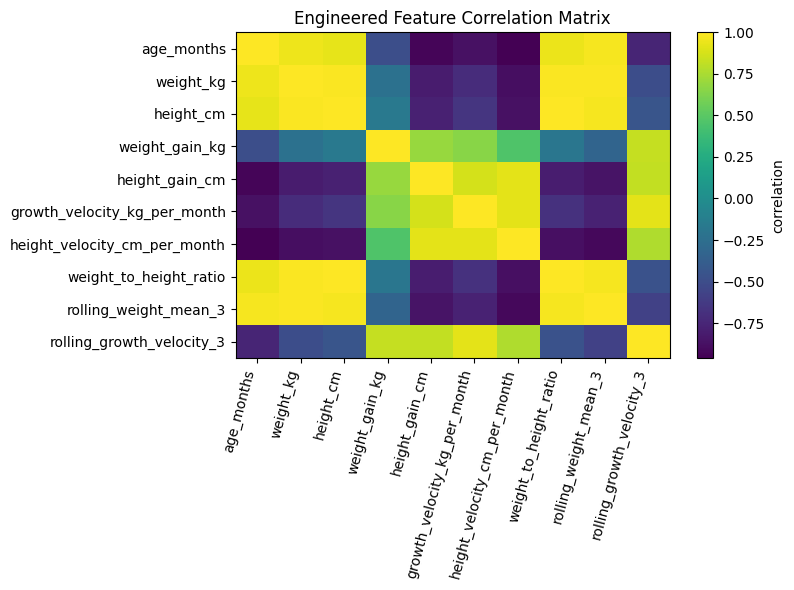

Saved figure: /mnt/data/ccgi_step10_work/reports/figures/feature_engineering_correlation_matrix.png


In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(numeric_features)), numeric_features, rotation=75, ha="right")
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title("Engineered Feature Correlation Matrix")
plt.tight_layout()

correlation_path = figures_dir / "feature_engineering_correlation_matrix.png"
plt.savefig(correlation_path, dpi=160)
plt.show()

print("Saved figure:", correlation_path)

## 14. Interpretation for the Project

The engineered features add information that the raw columns alone do not show clearly.

| Engineered feature | Mathematical idea | Project interpretation |
|---|---|---|
| `weight_gain_kg` | difference between consecutive records | how much weight changed since previous measurement |
| `growth_velocity_kg_per_month` | change divided by time | speed of growth over time |
| `rolling_weight_mean_3` | local average over recent records | smoother view of development |
| `weight_to_height_ratio` | ratio between two body measurements | simple body proportion signal |
| `growth_velocity_z_score` | standardized distance from mean | whether growth velocity is high or low relative to sample |

This helps the project move from isolated measurements to a trajectory-based growth profile.

## 15. Learning Reflection

What I learned in this notebook:

1. Feature engineering is not random column creation. It should be connected to formulas and the problem domain.
2. Time series analysis starts by respecting the order of measurements.
3. Difference, velocity, rolling average and z-score are simple but powerful mathematical tools.
4. Engineered features can later improve regression, classification, clustering and dimensionality reduction.
5. A responsible ML project must explain both the value and the limitations of its signals.

This notebook is intentionally written as a learning stage. The formulas are kept visible because the goal is to show how the mathematical idea becomes Python code.

## 16. Limitations and Responsible Use

This notebook uses a small prototype Cane Corso dataset for temporal demonstration. It is useful for learning the method, but it is not enough for real veterinary conclusions.

The outputs should be interpreted as:

```text
educational growth-monitoring signals
```

not as:

```text
veterinary diagnosis
medical advice
pedigree proof
breed certification
```

A future version could apply the same feature engineering to larger repeated-measurement records if such data is available and responsibly documented.